<a href="https://colab.research.google.com/github/BenT034/Afstuderen_tests/blob/main/embedding_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Embedding Model Experiment
**Graduation Project — Requirement Analyse Engine**

In deze notebook test je hoe verschillende SBERT-modellen requirements en testdocumenten embedden en matchen.

### Wat gaan we doen?
1. Installeer sentence-transformers
2. Laad een paar requirements en testdocumenten
3. Embed ze met een model naar keuze
4. Bekijk welke requirements en tests dicht bij elkaar liggen
5. Vergelijk meerdere modellen

In [13]:
# ── Stap 1: Installeer benodigde packages ──────────────────────────────────
!pip install sentence-transformers -q

In [14]:
# ── Stap 2: Imports ────────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer, util
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

print('✅ Imports klaar')
print(f'GPU beschikbaar: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

✅ Imports klaar
GPU beschikbaar: True
GPU: Tesla T4


In [15]:
# ── Stap 3: Definieer requirements en testdocumenten ───────────────────────
# ✏️  Pas deze aan naar jouw eigen requirements en tests!

requirements = [
    "REQ-01: Het systeem moet alle fouten opslaan in een permanente opslaglocatie",
    "REQ-02: Gebruikers moeten zich kunnen aanmelden via OAuth2",
    "REQ-03: Het systeem moet binnen twee seconden reageren op alle API-verzoeken",
    "REQ-04: Alle opgeslagen gegevens moeten versleuteld worden met AES-256",
    "REQ-05: Het systeem moet een e-mailmelding sturen bij een kritieke fout",
    "REQ-06: Het systeem moet alle foutmeldingen registreren in de database",  # duplicate van REQ-01
    "REQ-07: Het systeem moet auditlogs bijhouden van alle wijzigingen aan gebruikersrechten",
    "REQ-08: Gebruikers moeten hun wachtwoord kunnen resetten via een e-maillink",
    "REQ-09: Het systeem moet mislukte inlogpogingen na vijf keer tijdelijk blokkeren",
    "REQ-10: Het systeem moet een waarschuwing tonen wanneer een bestand groter is dan 10 MB",
    "REQ-11: Het systeem moet geüploade bestanden valideren op toegestaan bestandstype",
    "REQ-12: Het systeem moet iedere nacht automatisch een back-up van de database maken",
    "REQ-13: Het systeem moet een back-upherstel kunnen uitvoeren binnen vijftien minuten",
    "REQ-14: Het systeem moet alle API-aanroepen voorzien van een unieke request-id",
    "REQ-15: Het systeem moet een melding registreren wanneer een externe service niet beschikbaar is",
    "REQ-16: Het systeem moet gebruikers automatisch afmelden na dertig minuten inactiviteit",
]

tests = [
    """TEST-01: Verificatie van foutopslag
    Doel: Controleren of het systeem fouten correct opslaat in de database.
    Precondities: Het systeem is actief en de database is bereikbaar.
    Stappen:
      1. Simuleer een systeemfout door een ongeldige API-aanroep te doen.
      2. Navigeer naar de logtabel in de database.
      3. Zoek naar de meest recente foutmelding.
    Verwacht resultaat: De gesimuleerde fout is zichtbaar in de logtabel met een correcte timestamp, foutcode en omschrijving.
    Postcondities: De logtabel bevat minimaal één nieuwe entry na de test.""",

    """TEST-02: OAuth2 aanmeldingsstroom
    Doel: Valideren dat gebruikers succesvol kunnen inloggen via OAuth2.
    Precondities: Een geldige OAuth2-provider is geconfigureerd en een testaccount is beschikbaar.
    Stappen:
      1. Navigeer naar de inlogpagina van de applicatie.
      2. Klik op de OAuth2-aanmeldknop.
      3. Voer geldige inloggegevens in bij de OAuth2-provider.
      4. Bevestig de toegangsrechten.
    Verwacht resultaat: De gebruiker wordt doorgestuurd naar de applicatie en is succesvol aangemeld. Een geldig sessietoken is aangemaakt.
    Postcondities: De gebruiker heeft een actieve sessie in het systeem.""",

    """TEST-03: API responstijd onder belasting
    Doel: Meten of de API binnen de gestelde tijdslimiet reageert onder normale belasting.
    Precondities: Het systeem draait in een testomgeving met representatieve data.
    Stappen:
      1. Verstuur 50 gelijktijdige API-verzoeken naar het systeem.
      2. Meet de responstijd van elk verzoek.
      3. Bereken de gemiddelde en maximale responstijd.
    Verwacht resultaat: Alle verzoeken worden beantwoord binnen twee seconden. De gemiddelde responstijd ligt onder de één seconde.
    Postcondities: Geen blijvende impact op systeemprestaties na de test.""",

    """TEST-04: Encryptie van opgeslagen gegevens
    Doel: Bevestigen dat alle opgeslagen gegevens versleuteld zijn en niet leesbaar zonder de juiste sleutel.
    Precondities: Het systeem heeft gegevens opgeslagen in de database.
    Stappen:
      1. Sla een testrecord op via de applicatie.
      2. Benader de database direct zonder gebruik van de applicatie.
      3. Lees de opgeslagen waarden op uit de database.
      4. Probeer de waarden zonder ontsleutelingssleutel te interpreteren.
    Verwacht resultaat: De opgeslagen waarden zijn onleesbaar zonder de ontsleutelingssleutel. De encryptie voldoet aan de AES-256 standaard.
    Postcondities: Het testrecord kan worden verwijderd na verificatie.""",

    """TEST-05: E-mailmelding bij kritieke fout
    Doel: Controleren of de beheerder automatisch een e-mailmelding ontvangt wanneer een kritieke fout optreedt.
    Precondities: Een geldig e-mailadres is geconfigureerd voor de beheerder. De mailserver is bereikbaar.
    Stappen:
      1. Simuleer een kritieke systeemfout via de testomgeving.
      2. Wacht maximaal 60 seconden.
      3. Controleer de inbox van het beheerders e-mailadres.
    Verwacht resultaat: De beheerder heeft een e-mail ontvangen met een duidelijke omschrijving van de fout, het tijdstip en de ernst.
    Postcondities: Het systeem heeft de fout geregistreerd en de melding verstuurd.""",

    """TEST-06: Sessie verloop na time-out
    Doel: Valideren dat een gebruikerssessie automatisch verloopt na een periode van inactiviteit.
    Precondities: Een gebruiker is aangemeld in het systeem.
    Stappen:
      1. Meld aan als testgebruiker.
      2. Voer geen acties uit gedurende de geconfigureerde time-out periode.
      3. Probeer na de time-out een beveiligde pagina te openen.
    Verwacht resultaat: De gebruiker wordt doorgestuurd naar de inlogpagina. De sessie is niet meer geldig.
    Postcondities: Er zijn geen actieve sessies meer voor de testgebruiker.""",
    """TEST-07: Auditlog van rechtenwijzigingen
    Doel: Controleren of wijzigingen aan gebruikersrechten correct worden vastgelegd in de auditlog.
    Precondities: Een beheerder is aangemeld en een testgebruiker bestaat in het systeem.
    Stappen:
      1. Meld aan als beheerder.
      2. Wijzig de rol of rechten van de testgebruiker.
      3. Open het auditlogoverzicht of raadpleeg de auditlog-opslag.
      4. Zoek naar de meest recente wijziging.
    Verwacht resultaat: De wijziging is zichtbaar in de auditlog met gebruikers-id, gewijzigde rechten, uitvoerende beheerder en timestamp.
    Postcondities: De auditlog bevat minimaal één nieuwe entry voor de uitgevoerde rechtenwijziging.""",

    """TEST-08: Wachtwoordreset via e-maillink
    Doel: Valideren dat een gebruiker het wachtwoord succesvol kan resetten via een resetlink per e-mail.
    Precondities: Een testgebruiker met een geldig e-mailadres bestaat in het systeem en de mailserver is bereikbaar.
    Stappen:
      1. Navigeer naar de inlogpagina.
      2. Kies de optie 'Wachtwoord vergeten'.
      3. Vul het e-mailadres van de testgebruiker in.
      4. Open de ontvangen e-mail en klik op de resetlink.
      5. Stel een nieuw geldig wachtwoord in.
      6. Meld aan met het nieuwe wachtwoord.
    Verwacht resultaat: De gebruiker ontvangt een geldige resetlink, kan het wachtwoord wijzigen en daarna succesvol aanmelden met het nieuwe wachtwoord.
    Postcondities: Het oude wachtwoord is ongeldig en het nieuwe wachtwoord is actief.""",

    """TEST-09: Tijdelijke blokkering na mislukte inlogpogingen
    Doel: Controleren of het systeem een account tijdelijk blokkeert na vijf mislukte inlogpogingen.
    Precondities: Een testgebruiker bestaat in het systeem met bekende geldige inloggegevens.
    Stappen:
      1. Navigeer naar de inlogpagina.
      2. Voer vijf keer achter elkaar een onjuist wachtwoord in voor dezelfde gebruiker.
      3. Probeer direct daarna opnieuw in te loggen, ook met het juiste wachtwoord.
    Verwacht resultaat: Na vijf mislukte pogingen wordt de gebruiker tijdelijk geblokkeerd en is aanmelden gedurende de blokkadeperiode niet mogelijk.
    Postcondities: De blokkadestatus van de gebruiker is vastgelegd volgens de configuratie van het systeem.""",

    """TEST-10: Waarschuwing bij groot bestand
    Doel: Verifiëren dat het systeem een waarschuwing toont wanneer een gebruiker een bestand groter dan 10 MB probeert te uploaden.
    Precondities: Een gebruiker is aangemeld en bevindt zich op de uploadpagina.
    Stappen:
      1. Selecteer een bestand van meer dan 10 MB.
      2. Start de uploadactie.
      3. Observeer de melding in de gebruikersinterface.
    Verwacht resultaat: Het systeem toont een duidelijke waarschuwing dat het bestand groter is dan 10 MB en informeert de gebruiker over de beperking of vervolgstap.
    Postcondities: De gebruiker heeft de waarschuwing gezien en de status van de upload is bekend.""",

    """TEST-11: Validatie van toegestaan bestandstype
    Doel: Controleren of het systeem alleen bestanden met toegestane bestandstypen accepteert.
    Precondities: Een gebruiker is aangemeld en bevindt zich op de uploadpagina. Een lijst met toegestane bestandstypen is geconfigureerd.
    Stappen:
      1. Selecteer een bestand met een niet-toegestaan bestandstype, bijvoorbeeld .exe.
      2. Probeer het bestand te uploaden.
      3. Herhaal de test met een toegestaan bestandstype, bijvoorbeeld .pdf.
    Verwacht resultaat: Het niet-toegestane bestand wordt geweigerd met een duidelijke foutmelding. Het toegestane bestand wordt geaccepteerd voor verdere verwerking.
    Postcondities: Alleen bestanden met toegestane bestandstypen zijn door het systeem geaccepteerd.""",

    """TEST-12: Nachtelijke automatische databaseback-up
    Doel: Bevestigen dat het systeem iedere nacht automatisch een back-up van de database uitvoert.
    Precondities: Het systeem is actief, de database bevat data en de back-upfunctionaliteit is geconfigureerd.
    Stappen:
      1. Controleer de geplande back-uptijd in de configuratie.
      2. Wacht tot na het geplande back-upmoment of forceer het geplande proces in een testomgeving.
      3. Controleer de back-uplocatie en de back-uplogs.
    Verwacht resultaat: Er is een nieuwe back-up aangemaakt op de juiste locatie met een correcte timestamp en zonder foutmeldingen in de logs.
    Postcondities: De meest recente back-up is beschikbaar voor hersteldoeleinden.""",

    """TEST-13: Herstel van databaseback-up binnen vijftien minuten
    Doel: Meten of een databaseback-up binnen vijftien minuten succesvol kan worden teruggezet.
    Precondities: Er is een geldige recente back-up beschikbaar en een testomgeving voor herstel is ingericht.
    Stappen:
      1. Start een herstelprocedure met de meest recente back-up.
      2. Meet de totale tijd vanaf het starten van het herstel tot het moment waarop de database weer beschikbaar is.
      3. Controleer of de gegevens correct zijn hersteld.
    Verwacht resultaat: Het herstel is binnen vijftien minuten voltooid en de herstelde database is consistent en bruikbaar.
    Postcondities: De testomgeving bevat een volledig herstelde database op basis van de gekozen back-up.""",

    """TEST-14: Unieke request-id voor API-aanroepen
    Doel: Valideren dat iedere API-aanroep een unieke request-id krijgt toegewezen en dat deze traceerbaar is in de logging.
    Precondities: Het systeem draait en API-logging is ingeschakeld.
    Stappen:
      1. Verstuur meerdere API-verzoeken kort achter elkaar.
      2. Inspecteer de responseheaders en/of de logs van het systeem.
      3. Vergelijk de request-id's van de uitgevoerde verzoeken.
    Verwacht resultaat: Iedere API-aanroep heeft een unieke request-id en deze id is terug te vinden in de logs voor traceerbaarheid.
    Postcondities: De logs bevatten meerdere unieke request-id's gekoppeld aan de uitgevoerde verzoeken.""",

    """TEST-15: Registratie van storing in externe service
    Doel: Controleren of het systeem een melding registreert wanneer een externe service niet beschikbaar is.
    Precondities: Het systeem is gekoppeld aan een externe service en logging of monitoring is geconfigureerd.
    Stappen:
      1. Maak de externe service tijdelijk onbereikbaar, bijvoorbeeld door de endpointconfiguratie te wijzigen of netwerktoegang te blokkeren.
      2. Start een proces dat afhankelijk is van de externe service.
      3. Controleer de logs, monitoringmeldingen of eventregistratie van het systeem.
    Verwacht resultaat: Het systeem registreert een duidelijke melding dat de externe service niet beschikbaar is, inclusief timestamp en context van de fout.
    Postcondities: De storing is vastgelegd in de daarvoor bedoelde log- of monitoringsvoorziening.""",

    """TEST-16: Automatisch afmelden na inactiviteit
    Doel: Valideren dat een gebruiker automatisch wordt afgemeld na dertig minuten inactiviteit.
    Precondities: Een gebruiker is succesvol aangemeld en de sessietime-out staat ingesteld op dertig minuten.
    Stappen:
      1. Meld aan als testgebruiker.
      2. Voer geen enkele actie uit gedurende dertig minuten.
      3. Probeer daarna een beveiligde pagina te openen of een actie uit te voeren.
    Verwacht resultaat: De gebruiker is automatisch afgemeld en moet opnieuw authenticeren om verder te gaan.
    Postcondities: De oorspronkelijke sessie is verlopen en kan niet meer gebruikt worden.""",
]

print(f'✅ {len(requirements)} requirements en {len(tests)} tests geladen')

✅ 16 requirements en 16 tests geladen


In [16]:
# ── Stap 4: Kies een model ─────────────────────────────────────────────────
# Probeer verschillende modellen door de MODEL_NAME aan te passen:
#
#  Klein & snel (Engels):    'all-MiniLM-L6-v2'
#  Iets beter (Engels):      'all-MiniLM-L12-v2'
#  Beste kwaliteit (Engels): 'all-mpnet-base-v2'
#  Sterk alternatief:        'BAAI/bge-small-en-v1.5'
#  Meertalig (NL + EN):      'paraphrase-multilingual-MiniLM-L12-v2'
#  Beste meertalig:          'BAAI/bge-m3'

MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'  # ✏️ Verander dit om een ander model te testen

print(f'Model laden: {MODEL_NAME}...')
start = time.time()
model = SentenceTransformer(MODEL_NAME)
load_time = time.time() - start
print(f'✅ Model geladen in {load_time:.1f}s')
print(f'Embedding dimensies: {model.get_sentence_embedding_dimension()}')

Model laden: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model geladen in 6.5s
Embedding dimensies: 384


In [17]:
# ── Stap 5: Embed requirements en tests ────────────────────────────────────
print('Requirements embedden...')
start = time.time()
req_embeddings = model.encode(requirements, convert_to_tensor=True, show_progress_bar=True)
req_time = time.time() - start

print(f'\nTests embedden...')
start = time.time()
test_embeddings = model.encode(tests, convert_to_tensor=True, show_progress_bar=True)
test_time = time.time() - start

print(f'\n✅ Klaar!')
print(f'Requirements: {req_time*1000:.0f}ms | Tests: {test_time*1000:.0f}ms')
print(f'Vector shape requirements: {req_embeddings.shape}')

Requirements embedden...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Tests embedden...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Klaar!
Requirements: 75ms | Tests: 71ms
Vector shape requirements: torch.Size([16, 384])


In [18]:
# ── Stap 6: Bereken similarity matrix ─────────────────────────────────────
cosine_scores = util.cos_sim(req_embeddings, test_embeddings).cpu().numpy()

# Maak een nette tabel
req_labels = [r.split(':')[0] for r in requirements]
test_labels = [t.split(':')[0] for t in tests]

df = pd.DataFrame(cosine_scores, index=req_labels, columns=test_labels)

print('Similarity matrix (cosine similarity, 0.0 - 1.0):')
print(df.round(2).to_string())

Similarity matrix (cosine similarity, 0.0 - 1.0):
        TEST-01  TEST-02  TEST-03  TEST-04  TEST-05  TEST-06  TEST-07  TEST-08  TEST-09  TEST-10  TEST-11  TEST-12  TEST-13  TEST-14  TEST-15  TEST-16
REQ-01     0.56     0.25     0.30     0.39     0.47     0.38     0.36     0.37     0.47     0.30     0.29     0.51     0.45     0.24     0.39     0.34
REQ-02     0.33     0.75     0.18     0.25     0.32     0.33     0.33     0.47     0.31     0.20     0.22     0.31     0.21     0.26     0.27     0.28
REQ-03     0.45     0.35     0.66     0.31     0.41     0.55     0.27     0.37     0.45     0.40     0.21     0.50     0.51     0.46     0.45     0.53
REQ-04     0.28     0.17     0.22     0.41     0.20     0.12     0.19     0.26     0.23     0.22     0.24     0.37     0.29     0.18     0.21     0.12
REQ-05     0.41     0.26     0.24     0.22     0.69     0.27     0.25     0.47     0.30     0.26     0.16     0.32     0.28     0.18     0.28     0.27
REQ-06     0.65     0.34     0.25     0.48  

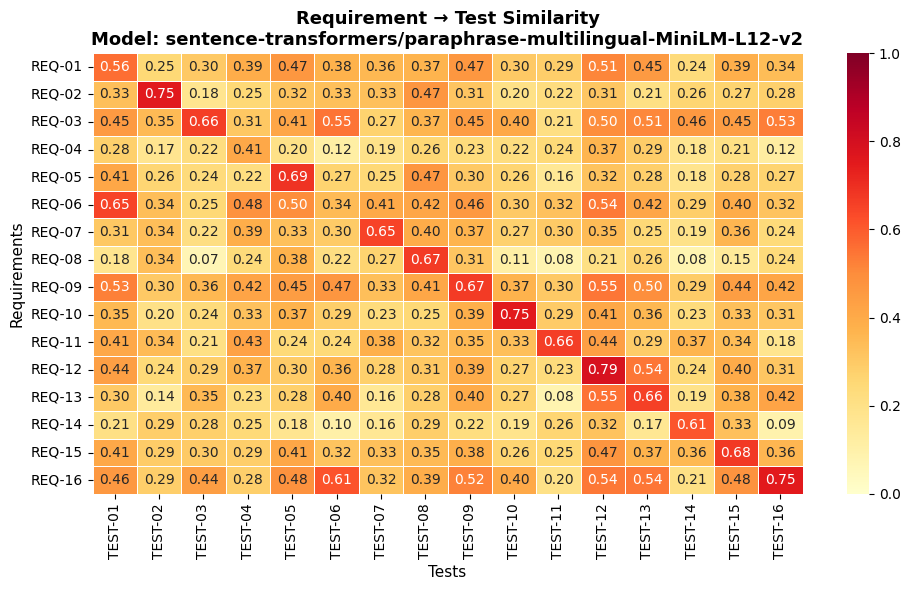

✅ Heatmap opgeslagen als similarity_heatmap.png


In [19]:
# ── Stap 7: Visualiseer als heatmap ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    cosine_scores,
    xticklabels=test_labels,
    yticklabels=req_labels,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title(f'Requirement → Test Similarity\nModel: {MODEL_NAME}', fontsize=13, fontweight='bold')
ax.set_xlabel('Tests', fontsize=11)
ax.set_ylabel('Requirements', fontsize=11)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap opgeslagen als similarity_heatmap.png')

In [20]:
# ── Stap 8: Beste match per requirement ───────────────────────────────────
THRESHOLD = 0.50  # ✏️ Pas aan: boven deze score = mogelijke match

print(f'Beste match per requirement (threshold: {THRESHOLD})\n')
print('-' * 70)

for i, req in enumerate(requirements):
    scores = cosine_scores[i]
    best_idx = np.argmax(scores)
    best_score = scores[best_idx]

    status = '✅ MATCH' if best_score >= THRESHOLD else '❌ GAP'

    print(f'{status} | Score: {best_score:.3f}')
    print(f'  REQ:  {req}')
    if best_score >= THRESHOLD:
        print(f'  TEST: {tests[best_idx]}')
    else:
        print(f'  TEST: geen match gevonden boven threshold')
    print()

Beste match per requirement (threshold: 0.5)

----------------------------------------------------------------------
✅ MATCH | Score: 0.560
  REQ:  REQ-01: Het systeem moet alle fouten opslaan in een permanente opslaglocatie
  TEST: TEST-01: Verificatie van foutopslag
    Doel: Controleren of het systeem fouten correct opslaat in de database.
    Precondities: Het systeem is actief en de database is bereikbaar.
    Stappen:
      1. Simuleer een systeemfout door een ongeldige API-aanroep te doen.
      2. Navigeer naar de logtabel in de database.
      3. Zoek naar de meest recente foutmelding.
    Verwacht resultaat: De gesimuleerde fout is zichtbaar in de logtabel met een correcte timestamp, foutcode en omschrijving.
    Postcondities: De logtabel bevat minimaal één nieuwe entry na de test.

✅ MATCH | Score: 0.755
  REQ:  REQ-02: Gebruikers moeten zich kunnen aanmelden via OAuth2
  TEST: TEST-02: OAuth2 aanmeldingsstroom
    Doel: Valideren dat gebruikers succesvol kunnen inloggen vi

In [21]:
# ── Stap 9: Duplicate detectie tussen requirements ────────────────────────
DUPLICATE_THRESHOLD = 0.85  # ✏️ Pas aan

req_sim = util.cos_sim(req_embeddings, req_embeddings).cpu().numpy()

print(f'Mogelijke duplicates (threshold: {DUPLICATE_THRESHOLD})\n')
print('-' * 70)

found = False
for i in range(len(requirements)):
    for j in range(i + 1, len(requirements)):
        score = req_sim[i][j]
        if score >= DUPLICATE_THRESHOLD:
            found = True
            print(f'⚠️  Score: {score:.3f}')
            print(f'  A: {requirements[i]}')
            print(f'  B: {requirements[j]}')
            print()

if not found:
    print('Geen duplicates gevonden boven threshold.')
    print('Probeer een lagere threshold als je toch duplicates verwacht.')

Mogelijke duplicates (threshold: 0.85)

----------------------------------------------------------------------
Geen duplicates gevonden boven threshold.
Probeer een lagere threshold als je toch duplicates verwacht.


In [22]:
# ── Stap 10: Vergelijk meerdere modellen ──────────────────────────────────
# Dit duurt even maar geeft een goed beeld van de verschillen

models_to_compare = [
    'all-MiniLM-L6-v2',
    'all-MiniLM-L12-v2',
    'BAAI/bge-small-en-v1.5',
    # 'all-mpnet-base-v2',        # ✏️ Uncomment voor meer modellen
    # 'paraphrase-multilingual-MiniLM-L12-v2',
]

results = []

for model_name in models_to_compare:
    print(f'\nTesten: {model_name}')

    m = SentenceTransformer(model_name)

    # Snelheid meten
    all_texts = requirements + tests
    start = time.time()
    embeddings = m.encode(all_texts, convert_to_tensor=True)
    elapsed = time.time() - start
    speed = len(all_texts) / elapsed

    # REQ-01 vs TEST-01 score (verwacht hoog)
    r1 = m.encode(requirements[0], convert_to_tensor=True)
    t1 = m.encode(tests[0], convert_to_tensor=True)
    match_score = util.cos_sim(r1, t1).item()

    # REQ-01 vs TEST-06 score (verwacht laag)
    t6 = m.encode(tests[5], convert_to_tensor=True)
    nomatch_score = util.cos_sim(r1, t6).item()

    # REQ-01 vs REQ-06 (NL duplicate, verwacht hoog)
    r6 = m.encode(requirements[5], convert_to_tensor=True)
    dup_score = util.cos_sim(r1, r6).item()

    results.append({
        'Model': model_name.split('/')[-1],
        'Dims': m.get_sentence_embedding_dimension(),
        'Snelheid (zin/s)': f'{speed:.0f}',
        'REQ01↔TEST01 (match)': f'{match_score:.3f}',
        'REQ01↔TEST06 (geen match)': f'{nomatch_score:.3f}',
        'REQ01↔REQ06 (NL dup)': f'{dup_score:.3f}',
    })
    print(f'  ✅ match: {match_score:.3f} | geen match: {nomatch_score:.3f} | NL dup: {dup_score:.3f} | {speed:.0f} zin/s')

print('\n' + '='*70)
print('VERGELIJKING OVERZICHT')
print('='*70)
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))


Testen: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✅ match: 0.557 | geen match: 0.496 | NL dup: 0.630 | 259 zin/s

Testen: all-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✅ match: 0.524 | geen match: 0.274 | NL dup: 0.571 | 977 zin/s

Testen: BAAI/bge-small-en-v1.5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✅ match: 0.783 | geen match: 0.699 | NL dup: 0.799 | 985 zin/s

VERGELIJKING OVERZICHT
            Model  Dims Snelheid (zin/s) REQ01↔TEST01 (match) REQ01↔TEST06 (geen match) REQ01↔REQ06 (NL dup)
 all-MiniLM-L6-v2   384              259                0.557                     0.496                0.630
all-MiniLM-L12-v2   384              977                0.524                     0.274                0.571
bge-small-en-v1.5   384              985                0.783                     0.699                0.799


## 💡 Wat kun je hieruit leren?

**Match score (REQ01↔TEST01):** Hoe goed herkent het model dat een requirement en test over hetzelfde gaan? Hoger = beter.

**Geen match score (REQ01↔TEST06):** Hoe goed onderscheidt het model niet-gerelateerde teksten? Lager = beter.

**NL duplicate score (REQ01↔REQ06):** Herkent het model dat een Nederlandse en Engelse requirement hetzelfde betekenen? Hoger = beter voor meertalige aanpak.

**Threshold bepalen:** Kijk naar de verdeling van scores — waar zit de natuurlijke grens tussen match en geen match?

---

### Volgende stap
Probeer je **eigen requirements en testdocumenten** in stap 3 in te vullen en kijk hoe het model reageert op jouw echte data!